# Final Report - Data Science

**Important**: this report may be written in either **Portuguese or English**. However, the selected language must be used consistently throughout the entire report. Mixing Portuguese and English is not allowed.

## Bachelor's Degree in Computer Science / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Luiz Henrique Matoso` - `luiz.matoso@pucpr.edu.br`

# Import the libs you need

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data

Below, load the data using pandas and perform all necessary data cleaning to ensure that the data types are correct for further analysis.

In [3]:
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

display(df.head())

print("Shape:", df.shape)

df.info()

display(df.describe())

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


Shape: (235795, 56)
<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasOb

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [4]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Missing values: {missing_values}")

# Check for duplicated rows
duplicated_rows = df.duplicated().sum()
print(f"Duplicated rows: {duplicated_rows}")

# The dataset documentation explicitly states that FILENAME can be ignored,
# since it is only an identifier and is not one of the predictive features.
df = df.drop(columns=["FILENAME"])

# Verify that the target contains only the expected binary classes:
# 0 = phishing and 1 = legitimate.
expected_labels = {0, 1}
actual_labels = set(df["label"].unique())

if actual_labels != expected_labels:
    raise ValueError(f"Unexpected label values found: {actual_labels}")

# Verify the resulting dataset structure
print(f"Shape after cleaning: {df.shape}")
print("\nData types:")
print(df.dtypes.value_counts())

Missing values: 0
Duplicated rows: 0
Shape after cleaning: (235795, 55)

Data types:
int64      41
float64    10
str         4
Name: count, dtype: int64


# Statistical Description

In [5]:
# Statistical description of the dataset

n_instances = df.shape[0]
n_columns = df.shape[1]
n_features = n_columns - 1  # excluding the target variable

print(f"Number of instances: {n_instances}")
print(f"Number of features: {n_features}")
print("Task: Binary classification")
print("Target variable: label")
print("Number of classes:", df["label"].nunique())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (%):")
print(df["label"].value_counts(normalize=True).mul(100).round(2))

Number of instances: 235795
Number of features: 54
Task: Binary classification
Target variable: label
Number of classes: 2

Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Class distribution (%):
label
1    57.19
0    42.81
Name: proportion, dtype: float64


The dataset contains 235,795 instances and 54 predictive features after removing the `FILENAME` identifier. The task is a binary classification problem in which the target variable `label` indicates whether a webpage is phishing (`0`) or legitimate (`1`).

The two classes are relatively balanced, with approximately 42.81% phishing instances and 57.19% legitimate instances. Therefore, there is no severe class imbalance in the dataset.

# Univariate data analysis

For the univariate analysis, 20 features were selected to represent different aspects of the dataset, including URL structure, domain characteristics, textual composition, HTML content, and reference behavior.

The selected variables were chosen because they have interpretable meanings in the context of phishing detection and can later support meaningful multivariate analyses.

In [6]:
selected_features = [
    "URLLength",
    "DomainLength",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "LineOfCode",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "NoOfImage",
    "NoOfSelfRef",
    "NoOfExternalRef"
]

In [7]:
def analyze_numeric_feature(feature, limit_99=False):
    data = df[feature]

    print(f"Feature: {feature}")
    print(f"Mean: {data.mean():.4f}")
    print(f"Standard deviation: {data.std():.4f}")
    print(f"Skewness: {data.skew():.4f}")
    print(f"Kurtosis: {data.kurt():.4f}")
    print(f"Minimum: {data.min()}")
    print(f"Median: {data.median()}")
    print(f"Maximum: {data.max()}")

    plot_data = data
    title = f"Distribution of {feature}"

    if limit_99:
        upper_limit = data.quantile(0.99)
        print(f"99th percentile: {upper_limit}")

        plot_data = data[data <= upper_limit]
        title += " (up to 99th percentile)"

    plt.figure(figsize=(8, 4))
    plt.hist(plot_data, bins=50)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

### 1. URL Length

`URLLength` represents the total number of characters in the URL.

This variable was selected because unusually long URLs may contain additional paths, parameters, subdomains, or encoded information, making URL length a potentially relevant characteristic when analyzing phishing websites.

Feature: URLLength
Mean: 34.5731
Standard deviation: 41.3142
Skewness: 53.3217
Kurtosis: 5914.0090
Minimum: 13
Median: 27.0
Maximum: 6097
99th percentile: 144.0


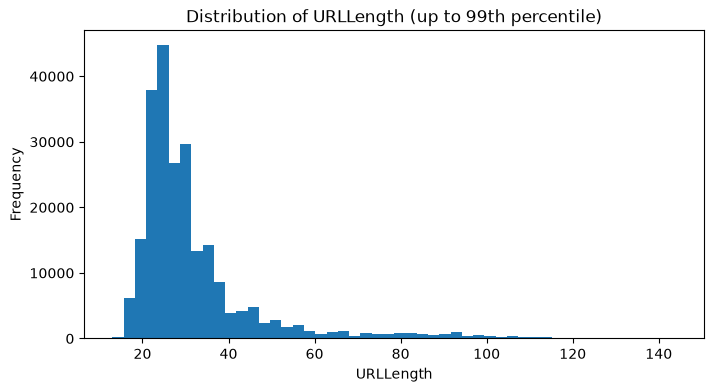

In [8]:
analyze_numeric_feature("URLLength", limit_99=True)

The distribution of `URLLength` is strongly right-skewed. Most URLs are relatively short, while a small number of observations contain exceptionally long URLs.

The mean URL length is approximately 34.57 characters, while the median is 27 characters. The higher mean is consistent with the strong positive skewness caused by unusually long URLs.

The standard deviation is approximately 41.31 characters, indicating considerable variability. The maximum URL length is 6,097 characters, which is substantially higher than the typical values and contributes to the extreme skewness and kurtosis.

For visualization purposes, the histogram was limited to the 99th percentile, corresponding to URLs with up to 144 characters. This restriction was applied only to the visualization; no observations were removed from the dataset or from the statistical calculations.

### 2. Domain Length

`DomainLength` represents the total number of characters in the domain name.

This variable was selected because domain length may reflect differences in naming patterns between legitimate and phishing websites. Unusually long domains can result from additional words, subdomains, or attempts to imitate legitimate services.

Feature: DomainLength
Mean: 21.4704
Standard deviation: 9.1508
Skewness: 2.5134
Kurtosis: 10.6602
Minimum: 4
Median: 20.0
Maximum: 110


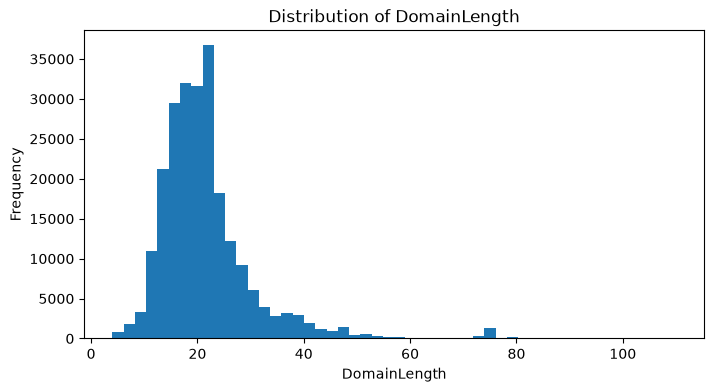

In [9]:
analyze_numeric_feature("DomainLength")

### 3. URL Similarity Index

`URLSimilarityIndex` represents a similarity score associated with the URL structure.

This variable was selected because differences in URL structure may help characterize how closely a webpage resembles common or legitimate URL patterns, making it potentially relevant for phishing detection.

Feature: URLSimilarityIndex
Mean: 78.4308
Standard deviation: 28.9761
Skewness: -0.9899
Kurtosis: -0.4080
Minimum: 0.155574352
Median: 100.0
Maximum: 100.0


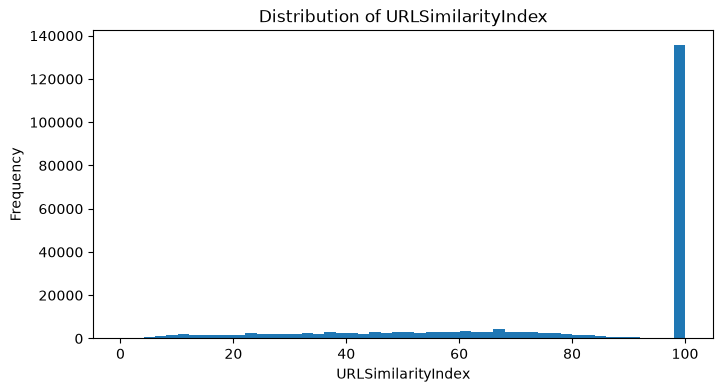

In [10]:
analyze_numeric_feature("URLSimilarityIndex")

The `URLSimilarityIndex` distribution is strongly concentrated at its upper limit, with a large proportion of observations having a value of 100.

The mean is approximately 78.43, while the median is 100, indicating that at least half of the observations are concentrated at the maximum value. The skewness of approximately -0.99 confirms a negatively skewed distribution, with a tail extending toward lower similarity values.

The standard deviation of approximately 28.98 indicates substantial dispersion despite the large concentration at 100. The negative kurtosis suggests a distribution flatter than a normal distribution, which is consistent with the combination of a strong peak at 100 and values spread across the lower range.

### 4. Char Continuation Rate

`CharContinuationRate` represents the continuity rate of characters in the URL.

This variable was selected because character sequencing and continuity patterns may differ between legitimate and phishing URLs, making it potentially useful for identifying structural irregularities.

Feature: CharContinuationRate
Mean: 0.8455
Standard deviation: 0.2166
Skewness: -1.1286
Kurtosis: 0.0565
Minimum: 0.0
Median: 1.0
Maximum: 1.0


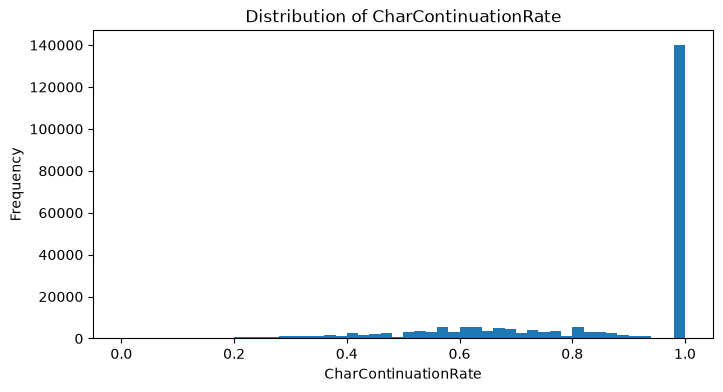

In [11]:
analyze_numeric_feature("CharContinuationRate")

The `CharContinuationRate` distribution is concentrated toward higher values, with a particularly large number of observations at 1.0.

The mean is approximately 0.85, while the median is 1.0. This indicates that at least half of the observations have the maximum continuation rate.

The skewness of approximately -1.13 confirms a negatively skewed distribution, with most observations concentrated at higher values and a tail extending toward lower values.

The standard deviation is approximately 0.22, indicating moderate variability across the dataset. The kurtosis is close to zero, suggesting that the overall shape is not substantially more or less heavy-tailed than a normal distribution, although the strong concentration at 1.0 makes the distribution clearly non-normal.

### 5. TLD Legitimate Probability

`TLDLegitimateProb` represents the estimated probability associated with the legitimacy of a top-level domain (TLD).

This variable was selected because different TLDs may exhibit different prevalence among legitimate and phishing websites, making the probability associated with a TLD potentially relevant for phishing detection.

Feature: TLDLegitimateProb
Mean: 0.2604
Standard deviation: 0.2516
Skewness: 0.0731
Kurtosis: -1.9738
Minimum: 0.0
Median: 0.0799628
Maximum: 0.5229071


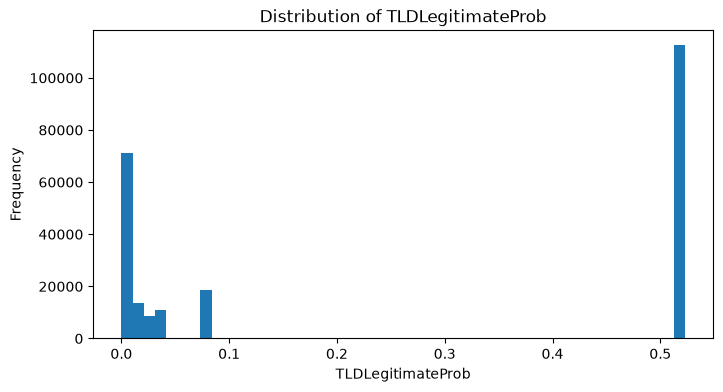

In [12]:
analyze_numeric_feature("TLDLegitimateProb")

The `TLDLegitimateProb` distribution is highly discrete, with observations concentrated around a small number of probability values rather than being continuously distributed.

The mean is approximately 0.26, while the median is approximately 0.08. Despite this difference, the skewness is close to zero (0.07), indicating little overall asymmetry.

The standard deviation is approximately 0.25, which is relatively large compared with the mean and reflects the strong separation between observations concentrated near zero and those close to the maximum value of approximately 0.52.

The kurtosis of approximately -1.97 indicates a considerably flatter distribution than a normal distribution. The histogram confirms that this variable does not follow a normal distribution and is instead concentrated around a few characteristic values.

### 6. URL Character Probability

`URLCharProb` represents a probability score derived from the characters that compose the URL.

This variable was selected because the composition and frequency of characters in a URL may differ between legitimate and phishing websites, making character-level patterns potentially relevant for phishing detection.

Feature: URLCharProb
Mean: 0.0557
Standard deviation: 0.0106
Skewness: -1.0643
Kurtosis: 1.4612
Minimum: 0.001082764
Median: 0.057970266
Maximum: 0.090823664


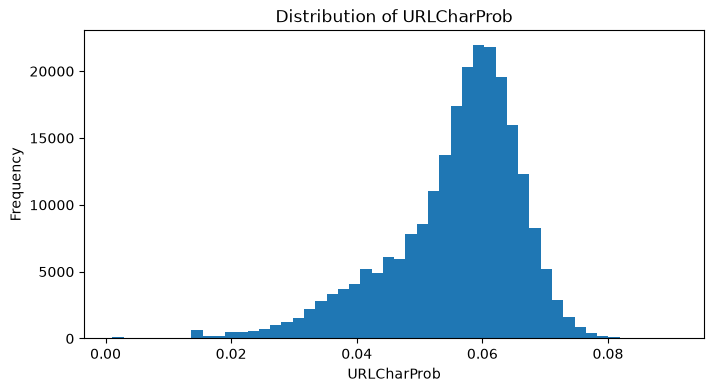

In [17]:
analyze_numeric_feature("URLCharProb")

The `URLCharProb` distribution is concentrated around values close to 0.06, with most observations falling approximately between 0.04 and 0.07.

The mean is approximately 0.0557 and the median is approximately 0.0580. Since the mean is lower than the median, the distribution presents a moderate negative skew, confirmed by the skewness value of approximately -1.06.

The standard deviation is approximately 0.0106, indicating relatively low dispersion around the mean. The kurtosis of approximately 1.46 indicates a distribution with heavier tails and a sharper concentration than a normal distribution.

The histogram also shows a longer tail toward lower probability values, which is consistent with the negative skewness.

### 7. Number of Subdomains

`NoOfSubDomain` represents the number of subdomains present in the URL.

This variable was selected because phishing URLs may use additional subdomains to imitate legitimate websites or obscure the actual domain being accessed.

Feature: NoOfSubDomain
Mean: 1.1648
Standard deviation: 0.6010
Skewness: 1.8094
Kurtosis: 7.7881
Minimum: 0
Median: 1.0
Maximum: 10


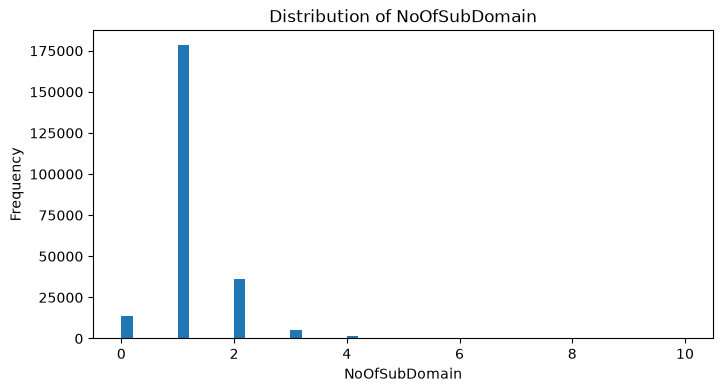

In [20]:
analyze_numeric_feature("NoOfSubDomain")

The `NoOfSubDomain` distribution is strongly concentrated around the value 1, which is also the median of the variable.

The mean is approximately 1.16, slightly higher than the median, indicating a positively skewed distribution. This is confirmed by the skewness value of approximately 1.81.

The standard deviation is approximately 0.60, showing relatively low variability around the typical value. However, some observations contain considerably more subdomains, with a maximum value of 10.

The kurtosis of approximately 7.79 indicates a strongly leptokurtic distribution, with a pronounced peak and heavier tails than a normal distribution. The histogram confirms that most observations are concentrated between 0 and 2 subdomains, while higher values are relatively rare.

### 8. Number of Letters in URL

`NoOfLettersInURL` represents the total number of alphabetic characters present in the URL.

This variable was selected because the composition and length of textual content within a URL may differ between legitimate and phishing websites, especially when attackers create longer or more descriptive URL paths.

Feature: NoOfLettersInURL
Mean: 19.4289
Standard deviation: 29.0903
Skewness: 58.4026
Kurtosis: 8587.8936
Minimum: 0
Median: 14.0
Maximum: 5191
99th percentile: 99.0


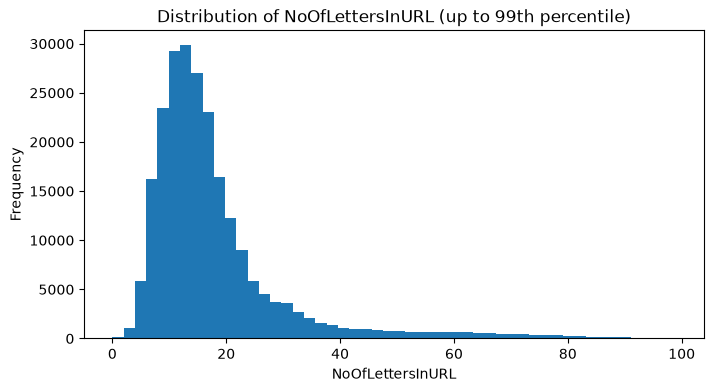

In [22]:
analyze_numeric_feature("NoOfLettersInURL", limit_99=True)

The `NoOfLettersInURL` distribution is extremely right-skewed. Most observations contain a relatively small number of letters, while a small number of URLs contain exceptionally large values.

The mean is approximately 19.43 letters and the median is 14, indicating that extreme observations pull the mean upward. This behavior is confirmed by the very high positive skewness of approximately 58.40.

The standard deviation is approximately 29.09, which is larger than the mean and indicates substantial variability. The maximum value of 5,191 letters is far from the typical observations and strongly affects the distribution.

The kurtosis of approximately 8,587.89 indicates an extremely heavy-tailed distribution with extreme observations.

For visualization purposes, the histogram was limited to the 99th percentile. This restriction affects only the visualization; all observations remain in the dataset and are included in the statistical calculations.

### 9. Letter Ratio in URL

`LetterRatioInURL` represents the proportion of alphabetic characters relative to the total number of characters in the URL.

This variable was selected because the composition of a URL may differ between legitimate and phishing websites, and the proportion of letters can help characterize these structural differences.

Feature: LetterRatioInURL
Mean: 0.5159
Standard deviation: 0.1233
Skewness: -0.0664
Kurtosis: 0.0159
Minimum: 0.0
Median: 0.519
Maximum: 0.926


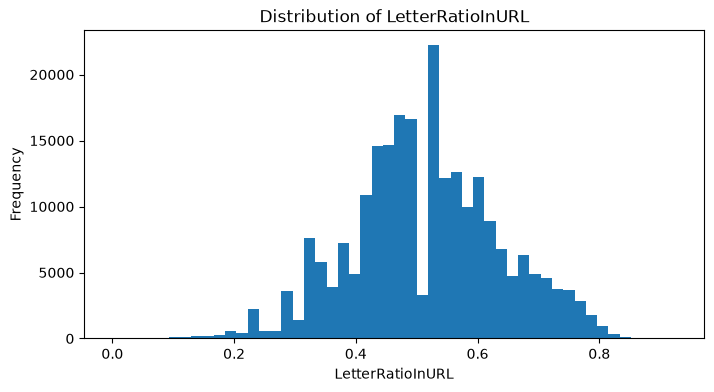

In [ ]:
analyze_numeric_feature("LetterRatioInURL")

The `LetterRatioInURL` distribution is approximately symmetric and centered around values close to 0.52.

The mean is approximately 0.516 and the median is 0.519, which are very similar. This is consistent with the skewness value of approximately -0.07, indicating almost no asymmetry in the distribution.

The standard deviation is approximately 0.123, showing moderate variability around the mean. Most observations are concentrated roughly between 0.3 and 0.8.

The kurtosis is approximately 0.02, which is close to zero and indicates a distribution with tail behavior and concentration relatively similar to a normal distribution, although the histogram still shows some irregularities caused by the discrete structure of URL composition.

### 10. Number of Digits in URL

`NoOfDegitsInURL` represents the total number of numeric characters present in the URL.

This variable was selected because phishing URLs may contain numeric sequences in paths, parameters, or generated identifiers, making the number of digits potentially relevant for distinguishing URL structures.

Feature: NoOfDegitsInURL
Mean: 1.8810
Standard deviation: 11.8867
Skewness: 94.8776
Kurtosis: 14318.7891
Minimum: 0
Median: 0.0
Maximum: 2011
99th percentile: 27.0


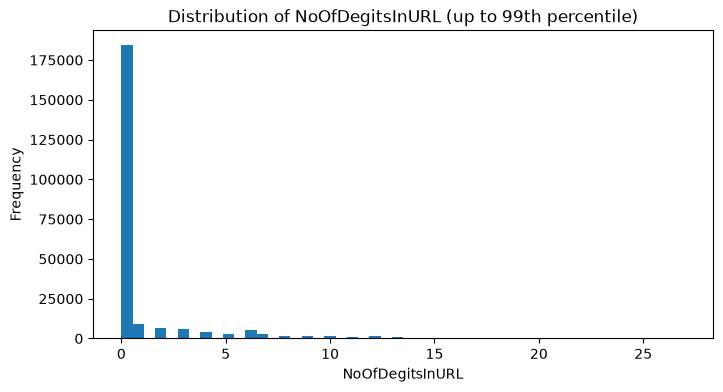

In [29]:
analyze_numeric_feature("NoOfDegitsInURL", limit_99=True)

The `NoOfDegitsInURL` distribution is extremely right-skewed. The median is 0, indicating that at least half of the URLs contain no digits, while a relatively small number of observations contain many numeric characters.

The mean is approximately 1.88 digits, which is substantially higher than the median because of extreme values in the right tail. This behavior is confirmed by the very high skewness of approximately 94.88.

The standard deviation is approximately 11.89, which is considerably larger than the mean and reflects the presence of highly atypical observations. The maximum value of 2,011 digits is extremely distant from the typical values.

The kurtosis of approximately 14,318.79 indicates an extremely heavy-tailed distribution dominated by rare extreme observations.

For visualization purposes, the histogram was limited to the 99th percentile. This restriction affects only the visualization; all observations remain in the dataset and are included in the statistical calculations.

### 11. Digit Ratio in URL

`DegitRatioInURL` represents the proportion of numeric characters relative to the total number of characters in the URL.

This variable was selected because the relative presence of digits may characterize URL construction patterns and help distinguish URLs containing unusual numeric sequences.

Feature: DegitRatioInURL
Mean: 0.0286
Standard deviation: 0.0709
Skewness: 3.2445
Kurtosis: 12.2363
Minimum: 0.0
Median: 0.0
Maximum: 0.684


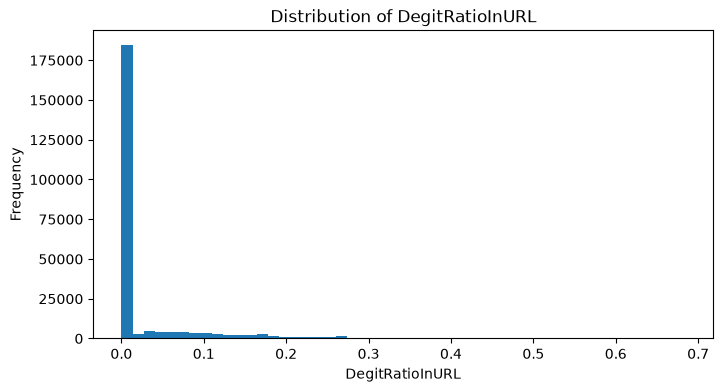

In [30]:
analyze_numeric_feature("DegitRatioInURL")

The `DegitRatioInURL` distribution is strongly concentrated at zero, indicating that a large proportion of URLs contain no numeric characters.

The mean is approximately 0.029, while the median is 0.0. This difference is consistent with the strong positive skewness of approximately 3.24, caused by a smaller number of URLs with considerably higher proportions of digits.

The standard deviation is approximately 0.071, which is relatively large compared with the mean and reflects the asymmetric distribution of the variable.

The kurtosis of approximately 12.24 indicates a strongly leptokurtic distribution with a pronounced concentration near zero and a relatively heavy right tail. The maximum observed ratio is approximately 0.684.

### 12. Number of Other Special Characters in URL

`NoOfOtherSpecialCharsInURL` represents the number of special characters in the URL that are not counted in the other specific character categories.

This variable was selected because unusual use of special characters may reflect more complex URL structures and can be relevant when characterizing potentially malicious URLs.

Feature: NoOfOtherSpecialCharsInURL
Mean: 2.3402
Standard deviation: 3.5276
Skewness: 47.4285
Kurtosis: 5657.8683
Minimum: 0
Median: 1.0
Maximum: 499
99th percentile: 13.0


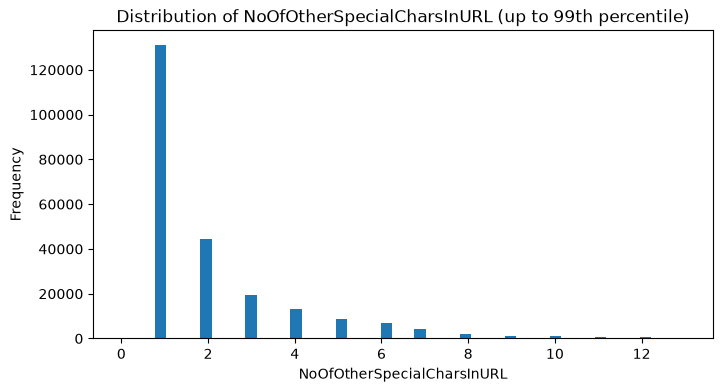

In [32]:
analyze_numeric_feature("NoOfOtherSpecialCharsInURL", limit_99=True)

The `NoOfOtherSpecialCharsInURL` distribution is strongly right-skewed. Most URLs contain only a small number of special characters, with a median of 1.

The mean is approximately 2.34, which is higher than the median due to a small number of observations with much larger values. This behavior is confirmed by the very high positive skewness of approximately 47.43.

The standard deviation is approximately 3.53, indicating considerable variability relative to the mean. The maximum value is 499, which is extremely distant from the typical observations.

The kurtosis of approximately 5,657.87 indicates an extremely heavy-tailed distribution with rare extreme observations.

For visualization purposes, the histogram was limited to the 99th percentile, corresponding to 13 special characters. This restriction affects only the visualization and does not remove any observations from the statistical calculations.

### 13. Special Character Ratio in URL

`SpacialCharRatioInURL` represents the proportion of special characters relative to the total number of characters in the URL.

This variable was selected because phishing URLs may contain a higher proportion of special characters to create complex paths, parameters, or misleading URL structures.

Feature: SpacialCharRatioInURL
Mean: 0.0633
Standard deviation: 0.0324
Skewness: 1.1841
Kurtosis: 0.9760
Minimum: 0.0
Median: 0.05
Maximum: 0.397


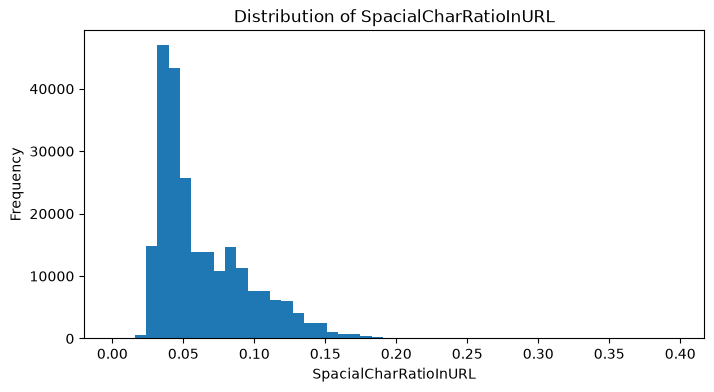

In [33]:
analyze_numeric_feature("SpacialCharRatioInURL")

The `SpacialCharRatioInURL` distribution is positively skewed, with most observations concentrated at relatively low values.

The mean is approximately 0.0633 and the median is 0.050, indicating that higher values in the right tail increase the mean. This behavior is consistent with the positive skewness of approximately 1.18.

The standard deviation is approximately 0.0324, showing moderate variability relative to the mean.

The kurtosis is approximately 0.98, indicating somewhat heavier tails and greater concentration than a normal distribution. The maximum observed ratio is approximately 0.397, while most observations remain substantially below this value.

### 14. HTTPS Usage

`IsHTTPS` indicates whether the webpage uses HTTPS.

This variable was selected because HTTPS is commonly associated with secure communication between the browser and the server, although its presence alone does not guarantee that a website is legitimate.

Mean: 0.7826
Standard deviation: 0.4125
Skewness: -1.3704
Kurtosis: -0.1219

Counts:
IsHTTPS
0     51256
1    184539
Name: count, dtype: int64


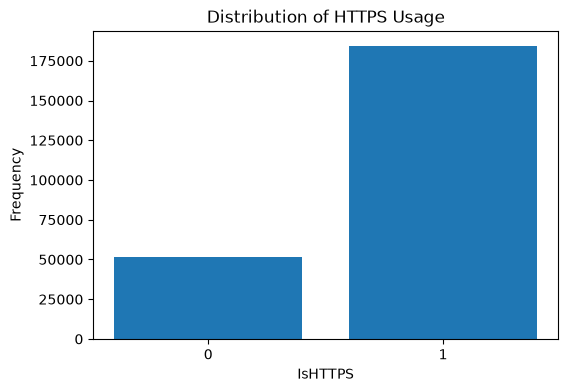

In [34]:
data = df["IsHTTPS"]

print(f"Mean: {data.mean():.4f}")
print(f"Standard deviation: {data.std():.4f}")
print(f"Skewness: {data.skew():.4f}")
print(f"Kurtosis: {data.kurt():.4f}")
print("\nCounts:")
print(data.value_counts().sort_index())

plt.figure(figsize=(6, 4))
counts = data.value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("IsHTTPS")
plt.ylabel("Frequency")
plt.title("Distribution of HTTPS Usage")
plt.show()

Most observations use HTTPS. Approximately 184,539 instances have `IsHTTPS = 1`, while 51,256 have `IsHTTPS = 0`.

The mean is approximately 0.783, which, for a binary variable, corresponds to the proportion of observations using HTTPS. Therefore, about 78.3% of the webpages in the dataset use HTTPS.

The standard deviation is approximately 0.413. The negative skewness of approximately -1.37 reflects the greater concentration of observations in class 1.

Since this is a binary variable, its distribution is Bernoulli rather than continuous, so the mean can be directly interpreted as the proportion of instances with HTTPS enabled.

### 15. Lines of Code

`LineOfCode` represents the number of lines of HTML source code associated with the webpage.

This variable was selected because webpage complexity may differ between legitimate and phishing websites, and the amount of HTML content can help characterize these structural differences.

Feature: LineOfCode
Mean: 1141.9004
Standard deviation: 3419.9505
Skewness: 53.0723
Kurtosis: 5597.1973
Minimum: 2
Median: 429.0
Maximum: 442666
99th percentile: 10388.0


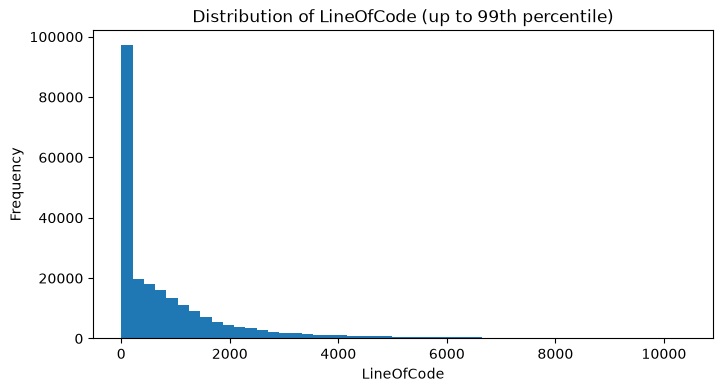

In [37]:
analyze_numeric_feature("LineOfCode", limit_99=True)

The `LineOfCode` distribution is extremely right-skewed. Most webpages contain a relatively limited number of lines of code, while a small number contain exceptionally large HTML documents.

The mean is approximately 1,141.99 lines, while the median is 429 lines. The substantially higher mean indicates that extreme values strongly influence the average. This behavior is confirmed by the very high positive skewness of approximately 53.07.

The standard deviation is approximately 3,419.95 lines, which is considerably larger than the mean and reflects the high variability caused by extreme observations. The maximum value of 442,666 lines is far from the typical range.

The kurtosis of approximately 5,597.20 indicates an extremely heavy-tailed distribution.

For visualization purposes, the histogram was limited to the 99th percentile, corresponding to 10,388 lines of code. This restriction affects only the visualization; all observations remain included in the statistical calculations.

# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

In [14]:
# again, feel free to place as many cells to plot the visualizations,
# as well as describe to the main findings

# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

In [15]:
# your code goes here

# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

```
Add your text here.
```

# Checkpoint Submission *(**Ignore this component in the final submission**)*

1. Save this report as a Jupyter Notebook (`.ipynb`), ensuring that all code cells are executed and their outputs are visible in the exported notebook;
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive named `EquipeXX.zip`, replacing XX with your team number;
6. Upload the ZIP file to Canvas.

# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [16]:
# use as many cells as needed

# Final Steps (Submission)


1. Run all cells in the notebook and make sure every cell is executed successfully, with all outputs visible;
2. Save this report as a Jupyter Notebook (`.ipynb`);
3. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
6. Upload the ZIP file to Canvas.